Необходимо скачать некоторые дополнительные библиотеки, которые не установлены по умолчанию

In [1]:
!pip install -q arch dtaidistance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 26.7 MB/s eta 0:00:00


Загрузим необходимые библиотеки и методы

In [2]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from matplotlib import dates as mdates
import seaborn as sns

from arch.unitroot import ADF, KPSS, PhillipsPerron

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL

from scipy.signal import detrend
from scipy.fft import fft, fftfreq, ifft
from scipy.stats import shapiro

from pywt import cwt, wavedec, waverec

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import (
    acorr_breusch_godfrey,
    acorr_ljungbox,
    acorr_lm,
    het_arch
)
from statsmodels.stats.stattools import jarque_bera
from statsmodels.api import qqplot

from dtaidistance import dtw

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

from warnings import filterwarnings

filterwarnings('ignore')
sns.set_style('darkgrid')

# Загрузка и исследование данных

Загрузим датасет и посмотрим на первые строки

In [3]:
df = pd.read_csv('retail_sales_mock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
df.index.freq = 'MS'
df.head(10)

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0
2020-08-01,10300,0,0
2020-09-01,10464,0,0


## Разведочный анализ данных (EDA)

### Построение графиков

С помощью функции `plot_time_series` можно будет построить график ряда. Также месяцы, когда были запущены рекламные кампании, будут отмечены вертикальными красными линиями, а месяцы, которые были праздничными - зелёными

In [4]:
def plot_time_series(column, figsize=(15, 7), cont='исходный ряд'):
    _, ax = plt.subplots(figsize=(15, 7))
    ax.plot(df[column])

    months = mdates.MonthLocator(interval=6)
    months_fmt = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(months_fmt)

    for column, label, color in zip(['Promotion', 'HolidayMonth'], ['Рекламная кампания', 'Праздничный месяц'], ['r', 'g']):
        ax.vlines(
            x=df[df[column] == 1].index, ymin=0, ymax=1, transform=ax.get_xaxis_transform(),
            color=color, linestyle='--', label=label
        )

    plt.suptitle(f'Количество продаж во времени ({cont})')
    plt.xlabel('Дата')
    plt.ylabel('Количество продаж')
    plt.legend()

    plt.show()

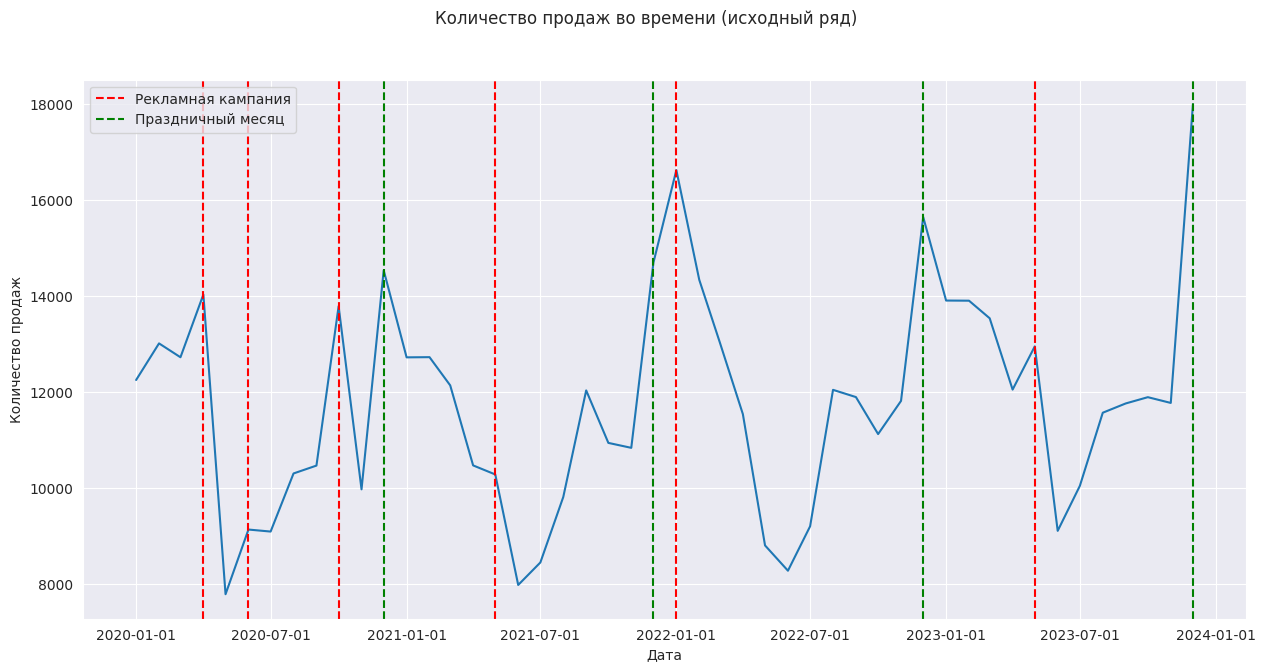

In [5]:
plot_time_series('SalesAmount')

Можно заметить, что:
- Ряд имеет довольно ярко выраженную сезонность с периодом в 12 месяцев
- Также визуально можно заметить плавно возрастающий (скорее всего линейный) тренд
- Праздничный месяц - это всегда декабрь
- Каждый раз разрыв между рекламными кампаниями всё увеличивался, однако чёткой закономерности не наблюдается

С помощью функции `barplot_per_period` можно отобразить статистику по различным периодам (напимер, по месяцам или годам)

In [6]:
def barplot_per_period(period, figsize=(15, 7)):
    _, ax = plt.subplots(figsize=figsize)
    if period == 'month':
        xlabel = 'Месяц'
    elif period == 'year':
        xlabel = 'Год'
    grouped = df.groupby(getattr(df.index, period))['SalesAmount'].sum().sort_values(ascending=False)
    sns.barplot(grouped, order=grouped.index, palette='rocket', ax=ax)
    for container in ax.containers:
        ax.bar_label(container)

    plt.suptitle('Количество продаж в зависимости от периода')
    plt.xlabel(xlabel)
    plt.ylabel('Количество продаж')

    plt.show()

Построим статистику суммарных продаж в зависимости от месяца

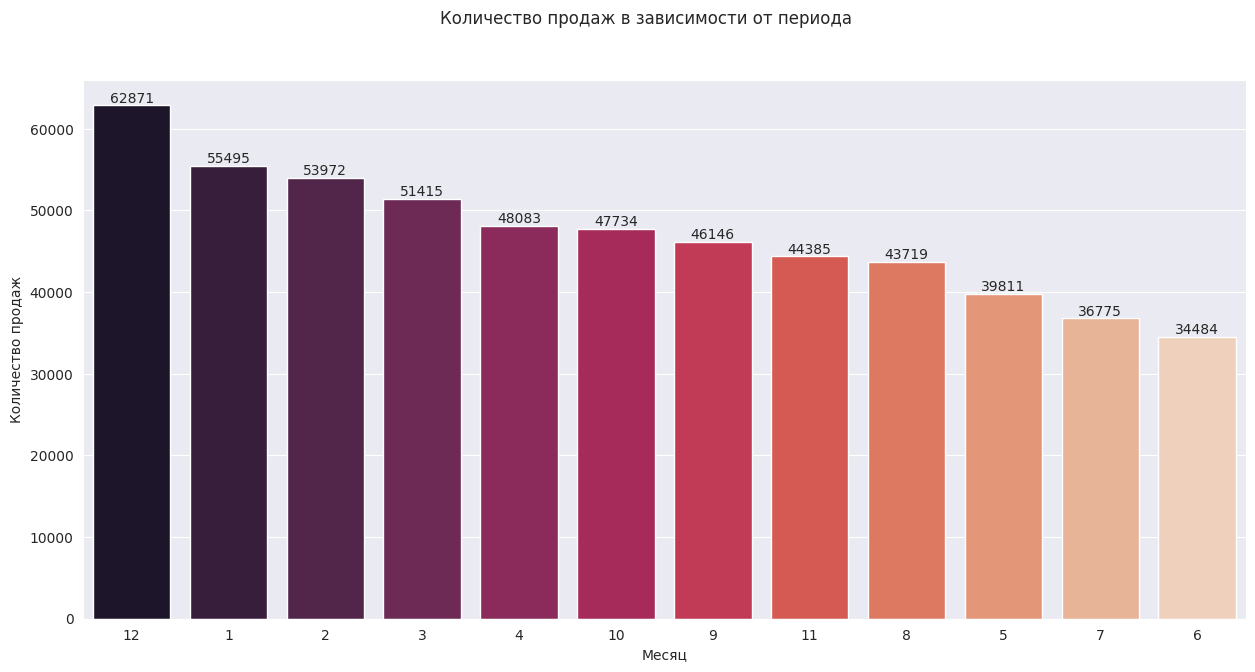

In [7]:
barplot_per_period('month')

Вырисовывается следующее:
- Больше всего продаж было в декабре
- Далее больше всего продаж у остальных зимних весяцев и первых двух весенних
- Среднее количетво продаж было осенью
- Меньше всего продаж было совершено поздней весной и летом

Теперь такую же статистику построим и для годов

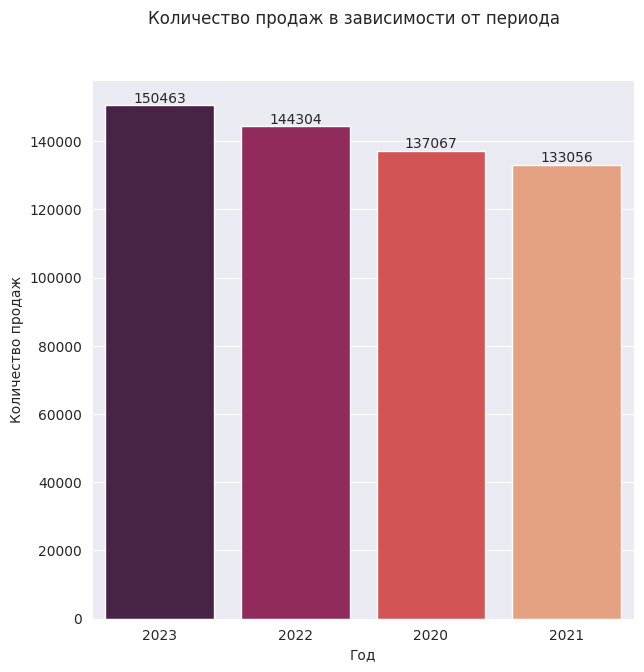

In [8]:
barplot_per_period('year', figsize=(7, 7))

Ну, в целом, тут комментировать особо и нечего - можно было бы сказать, что продажи растут со временем, если бы в 2021 году было бы больше продаж, чем в 2020

### Применение к ряду статистических тестов для проверки стационарности

Применим к ряду несколько статистических тестов на наличие единичного корня:
- Расширенный тест Дики-Фуллера
- Тест Филлипса-Перрона
- Тест Квятковского-Филлипса-Шмидта-Шина (KPSS сокращённо)

Первые 2 имеют нулевую гипотезу о том что в ряде имеется единичный корень и ряд нестационарен. Для того, чтобы отвергнуть эту гипотезу, нужно, чтобы p-value теста было меньше, чем заранее заданный уровень значимости. Мы бы хотели, чтобы p-value было меньше, чем уровеннь значимости. Отличия в 2 тестах заключаются в том, что они по-разному обрабатывают автокорреляцию (первый тест через лаговые разности в уравнении, а второй - через коррекцию стандартных ошибок). Также тест Филлипса-Перрона устойчив к гетероскедастичности остатков

У последнего теста всё, как раз наоборот, нулевая гипотеза говорит о том, что ряд стационарен. Чтобы отвергнуть эту гипотезу, нужно, чтобы p-value теста также было меньше, чем заранее заданный уровень значимости. Мы бы хотели, чтобы p-value было не меньше, чем уровень значимости

In [9]:
def apply_tests(name):
    column = df[name].dropna()
    statistic = []
    p_value = []
    critical_value_1 = []
    critical_value_5 = []
    critical_value_10 = []
    for test_function in [ADF, KPSS, PhillipsPerron]:
        stat = test_function(column)
        statistic.append(stat.stat)
        p_value.append(stat.pvalue)
        critical_value_1.append(stat.critical_values['1%'])
        critical_value_5.append(stat.critical_values['5%'])
        critical_value_10.append(stat.critical_values['10%'])
    return pd.DataFrame({
        'Значение статистики': statistic,
        'p-value': p_value,
        'Критическое значение статистики, 1%': critical_value_1,
        'Критическое значение статистики, 5%': critical_value_5,
        'Критическое значение статистики, 10%': critical_value_10
    }, index=['ADF', 'KPSS', 'PP'])

In [10]:
apply_tests('SalesAmount')

,Значение статистики,p-value,"Критическое значение статистики, 1%","Критическое значение статистики, 5%","Критическое значение статистики, 10%"
ADF,-4.514184,0.000185,-3.596636,-2.933297,-2.604991
KPSS,0.138846,0.426007,0.742800,0.461400,0.347500
PP,-2.122112,0.235717,-3.577848,-2.925338,-2.600774


Видим, что в тестах KPSS и Филлипса-Перрона нулевые гипотезы приняты, а в тесте Дики-Фулера отвергнута. Но получается, что в тесте Филлипса-Перрона пинята нулевая гипотеза о том, что ряд имеет единичный корень и нестационарен

Попробуем исправить это, продифференцировав его

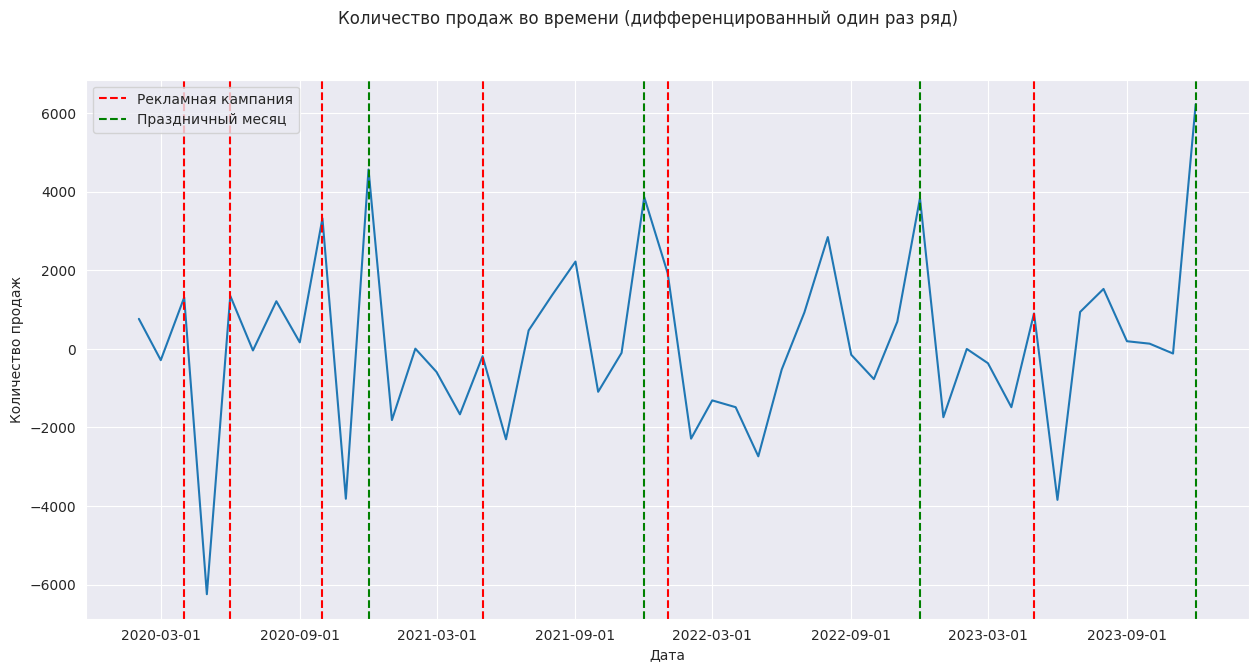

In [11]:
df['SalesAmountDiff'] = df['SalesAmount'].diff()
plot_time_series('SalesAmountDiff', cont='дифференцированный один раз ряд')

In [12]:
apply_tests('SalesAmountDiff')

,Значение статистики,p-value,"Критическое значение статистики, 1%","Критическое значение статистики, 5%","Критическое значение статистики, 10%"
ADF,-5.629594,1.097234e-06,-3.626652,-2.945951,-2.611671
KPSS,0.097468,5.981585e-01,0.742800,0.461400,0.347500
PP,-10.016679,1.721524e-17,-3.581258,-2.926785,-2.601541


Вот теперь нулевая гипотеза принимается только у теста KPSS, а у тестов Дики-Фуллера и Филлипса-Перрона она отвергается. Получается у дифференцированного ряда все 3 теста принимаются гипотезы о стационарности ряда, что так нужно моделям ARIMA и SARIMAX

Результаты тестов могут сказать, что при подборе гиперпараметров ряд скорее всего придётся дифференцировать, то есть нужно будет рассмотреть случаи, когда `d` = 1 и `D` = 1

### Построение графиков обычной и частичной автокорреляции

Воспользуемся готовыми функциями `plot_acf` и `plot_pacf` для отображения значений обычной и частичной автокорреляций для максимально возможного числа лагов

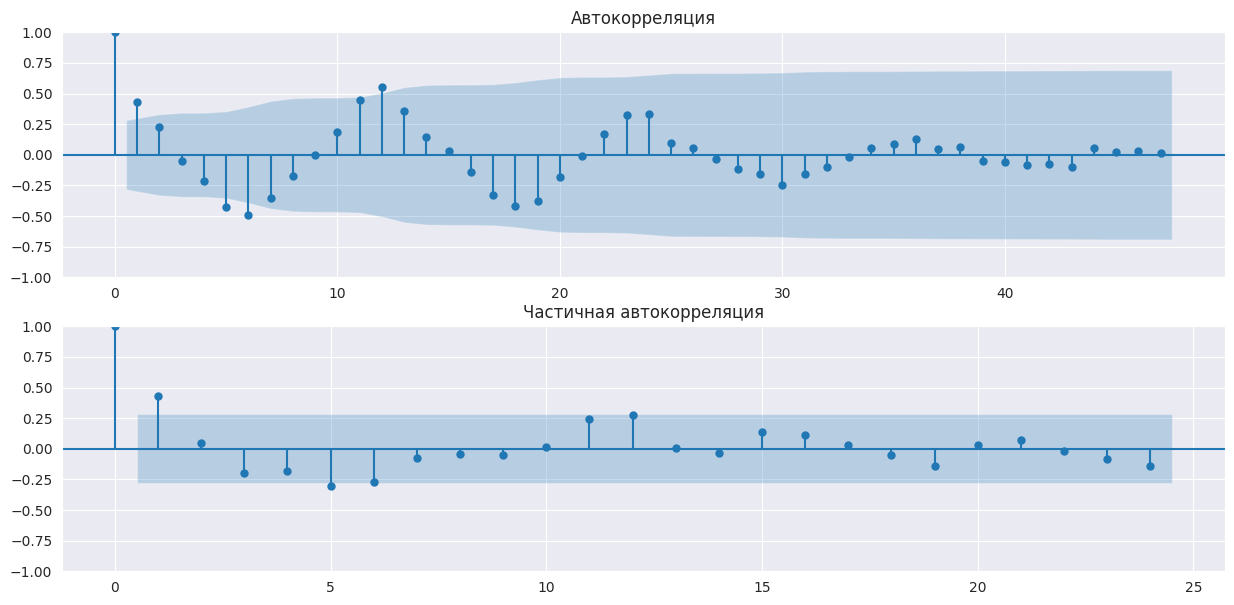

In [13]:
_, axes = plt.subplots(nrows=2, figsize=(15, 7))
plot_acf(df['SalesAmount'], lags=df.shape[0] - 1, ax=axes[0], title='Автокорреляция')
plot_pacf(df['SalesAmount'], lags=df.shape[0] // 2, ax=axes[1], title='Частичная автокорреляция')
plt.show()

Можно заметить следующее:
- Значения автокорреляции представляет косинусоиду, постепенно затихающую со временем, что подтверждает наличие сезонности в ряде
- У графика автокорреляции значимыми являются лаги, выходящую за синюю область, а это 1, 5, 6 и 12
- У графика частичной автокорреляции значимыми являются те же лаги
- Так как у ряда есть сезонность с периодом 12, то в качетве гиперпараметров `P` и `Q` для моделей SARIMA и SARIMAX можно будет использовать значения 0 или 1 при значении сезонности `s` = 12
- В качестве гиперпараметров `p` и `q` для моделей ARIMA, ARIMAX, SARIMA и SARIMAX также можно будет использовать значения 0 и 1. Также я бы добавил лаг под номером 2, а вот далее - нет. У нас мало данных и хотелось бы избежать переобучения, к тому же в данных есть сезонность

## Декомпозиция ряда

### Классическая декомпозиция

Начнём декомпозицию рядов с классических декомпозиций, то есть аддитивной, мультипликативной и STL

С помощью функции `plot_decomposition_results` можно для каждой из 3 моделей декомпозиции отобразить на графике полученные тренд, сезонность и остатки

In [14]:
def plot_decomposition_results(*results, figsize=(18, 9)):
    axes = plt.subplots(nrows=3, ncols=len(results), figsize=figsize)[1]

    months = mdates.MonthLocator(interval=6)
    months_fmt = mdates.DateFormatter('%Y-%m-%d')

    for i, (attr, title) in enumerate(zip(['trend', 'seasonal', 'resid'], ['Тренд', 'Сезонная компонента', 'Остатки'])):
        for j, (result, color, model) in enumerate(zip(results, ['blue', 'green', 'orange'], ['аддитивная модель', 'мультипликативная модель', 'STL'])):
            axes[i][j].plot(getattr(result, attr), color=color)
            axes[i][j].set_title(f'{title} ({model})')

    for ax in axes.flatten():
          ax.set_xticks(df.index)
          ax.set_xticklabels(labels=df.index, rotation=45)
          ax.xaxis.set_major_locator(months)
          ax.xaxis.set_major_formatter(months_fmt)

    plt.tight_layout()
    plt.show()

In [15]:
additive_result = seasonal_decompose(
    df['SalesAmount'],
    model='additive',
    period=12,
    extrapolate_trend='freq'
)

multiplicative_result = seasonal_decompose(
    df['SalesAmount'],
    model='multiplicative',
    period=12,
    extrapolate_trend='freq'
)

STL_result = STL(
    df['SalesAmount'],
    period=12,
    robust=True
).fit()

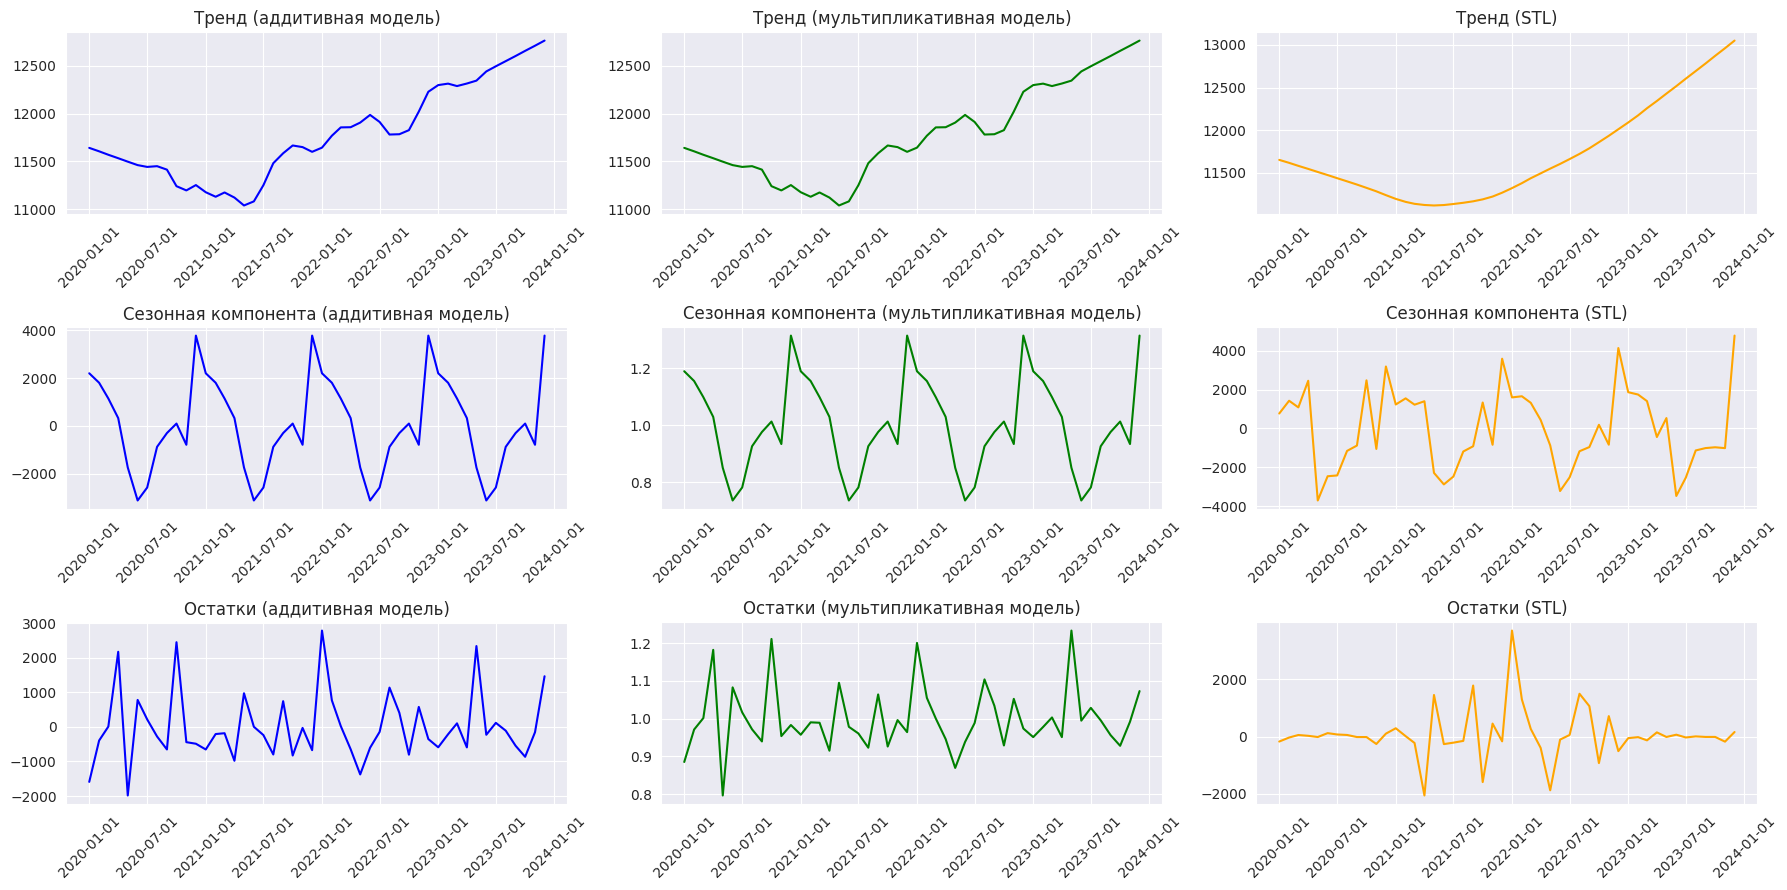

In [16]:
plot_decomposition_results(additive_result, multiplicative_result, STL_result)

Делаем выводы:
- Для аддитивной и мультипликативной моделей, в целом, получилис почти идентичный графики (разница только в масшатбе и области расположения)
- У аддитивной и мультипликативной моделей тренд сначала убывает, а потом возрастает. В целом, можно сказать, что он линейный, однако есть и значительные отклонения от линии
- У тренда из алгоритма STL такая же ситация, но он значительно более сглаженный, у него нет никаких колебаний
- Сезонная компонента у алгоритма STL очень сильно напоминает форму ряда и в ней не чувствуется, что какой-то шаблон повторяется через каждые 12 месяцев. Возможно это сильное влияние шума
- Интересно ведут себя остатки у модели STL, в начале и в конце они равны 0, а в середине испытывают сильные колебания, то есть их дисперсия со временем растёт, а потом уменьшается

### Спектральный анализ

Итак, теперь используем спектральный анализ для выявления наиболее интенсивных частот в спектре, благодаря этому можно будет определить сезонность данного ряда. Это ключевое отличие от используемых ранее методов декомпозиции, где необходмо было изначально указать им период сезонности

Важно не забыть убрать тренд из ряда, так как спектральный анализ предполагает, что у ряда нет тренда

In [17]:
df['SalesAmountDetrended'] = detrend(df['SalesAmount'].values, type='linear')
difference = df['SalesAmount'] - df['SalesAmountDetrended']

Теперь визуализируем ряд без тренда

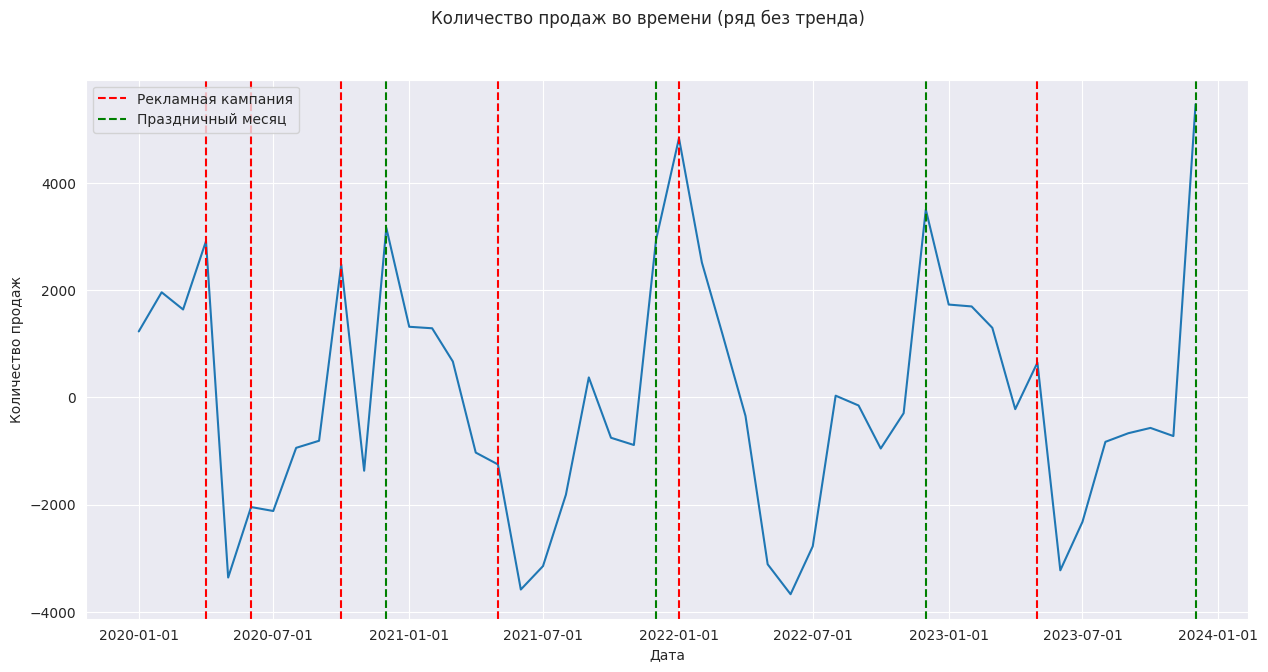

In [18]:
plot_time_series('SalesAmountDetrended', cont='ряд без тренда')

Тепер, наконец, изучим спектр такого ряда

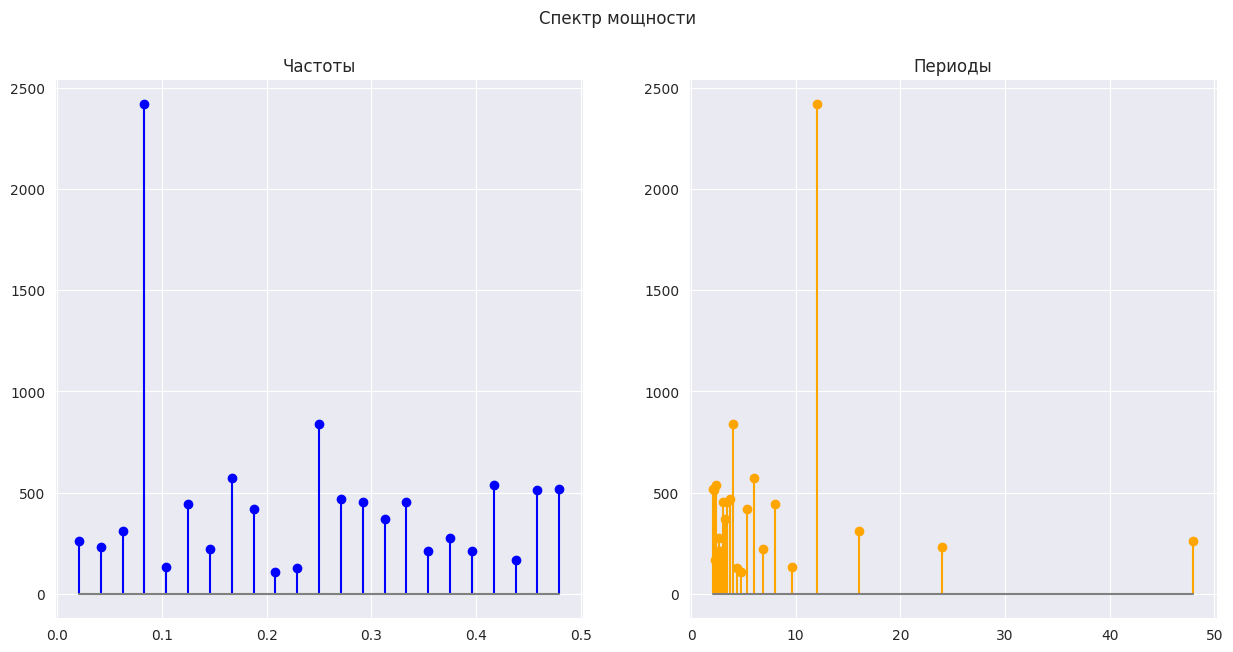

In [19]:
n = df.shape[0]
vals = fft(df['SalesAmountDetrended'])
freqs = fftfreq(n, 1)[1:(n // 2)]
amplitudes = 2 * np.abs(vals)[1:(n // 2)] / n

axes = plt.subplots(ncols=2, figsize=(15, 7))[1]

axes[0].stem(freqs, amplitudes, linefmt='blue', basefmt='gray')
axes[0].set_title('Частоты')

axes[1].stem(1 / freqs, amplitudes, linefmt='orange', basefmt='gray')
axes[1].set_title('Периоды')

plt.suptitle('Спектр мощности')
plt.show()

Наиболее интенсивная значение у частоты под номером 4. Так как всего у нас в ряде 48 объектов, то эта частота соответсвует периоду 48 / 4 = 12, то есть алгоритм Фурье уловил сезонность в 12 дней

С помощью функции `reconstruct_series` можно попробовать восстановить ряд, используя несколько наиболее интенсивных частот. Важно отметить, что это делается также с "детрендированным" рядом, поэтому при реконструкции нужно ещё добавить разницу между исходным рядом и рядом без тренда

In [20]:
def reconstruct_series(
    series, difference, vals, k, nrows=1, ncols=1, figsize=(15, 7)
):
    axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)[1].flatten()
    indices = np.argsort(np.abs(vals)[:(series.shape[0] // 2)])

    for ax, top_k in zip(axes, k):
        reconstructed_vals = np.zeros_like(vals)
        most_intensive = indices[-top_k:][::-1]
        for index in most_intensive:
            reconstructed_vals[[index, -index]] = vals[[index, -index]]

        ax.plot(series, color='blue', label='Истинный ряд')
        ax.plot(
            ifft(reconstructed_vals).real + difference,
            color='orange',
            label=f'Реконструкция, количество главных периодичностей - {top_k}'
        )
        ax.legend()

    plt.suptitle('Восстановление сигнала с помощью главных периодичностей')
    plt.tight_layout()
    plt.show()

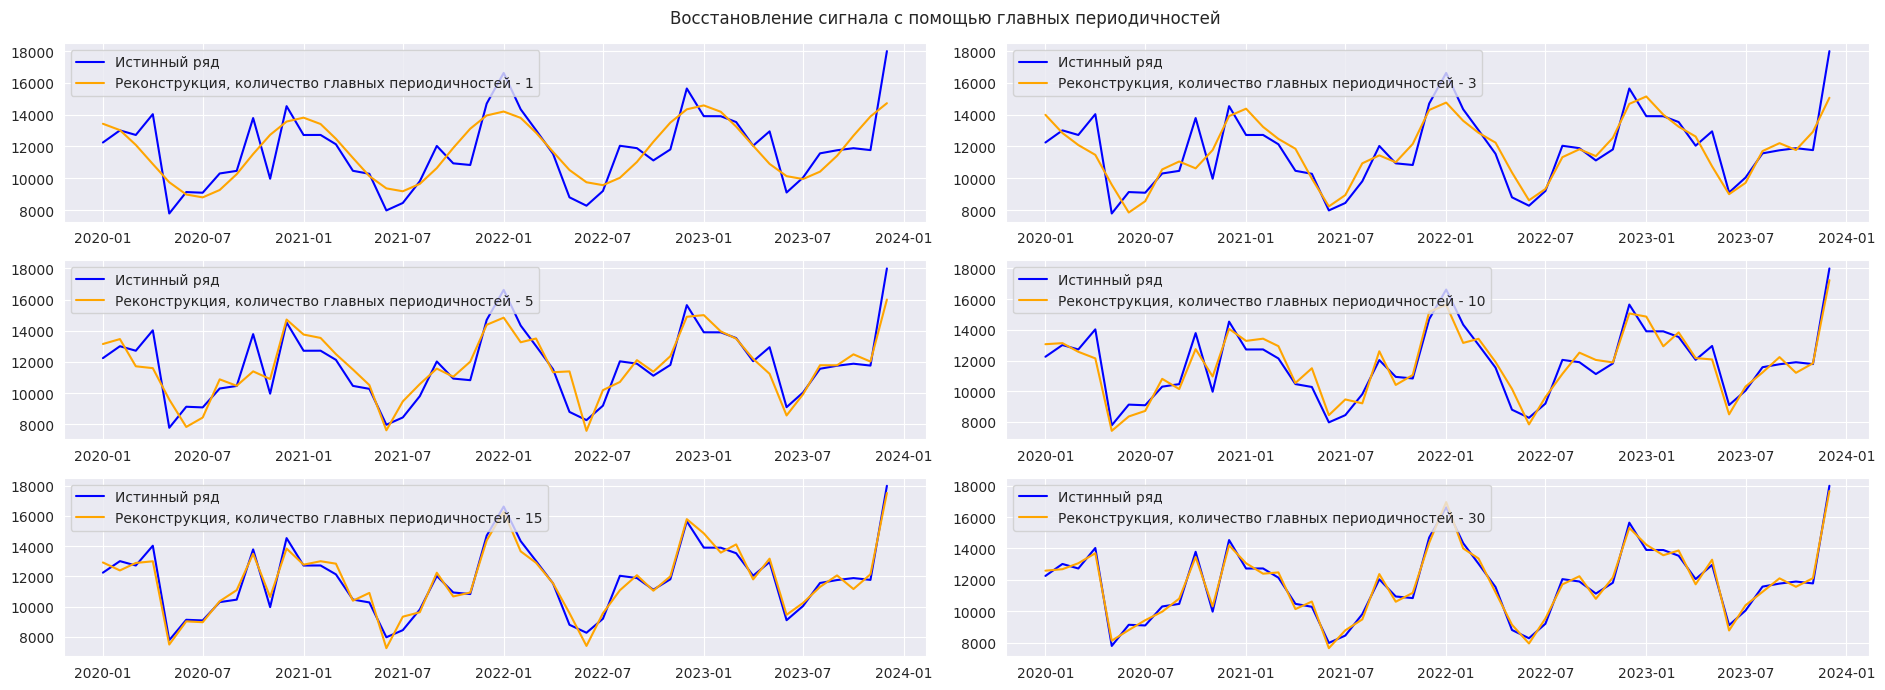

In [21]:
reconstruct_series(
    df['SalesAmount'], difference, vals,
     [1, 3, 5, 10, 15, 30], nrows=3, ncols=2,
    figsize=(19, 7)
)

Здесь можно видеть, как с ростом количества используемых наиболее интенсивных периодичностей растёт и качество восстановления

### Вейвлет-анализ

Вейвлет-анализ, в отличие от спектрального, не только сам выявит сезонность, но и покажет распределение сезонности во времени. Это логично, ведь в какое-то время у ряда могла быть одна сезонность, а в другое - совершенно другая. Это может оказаться полезной информацией

Итак, сначала построим скалограмму с помощью вейвлета Морле для "детрендированного" ряда

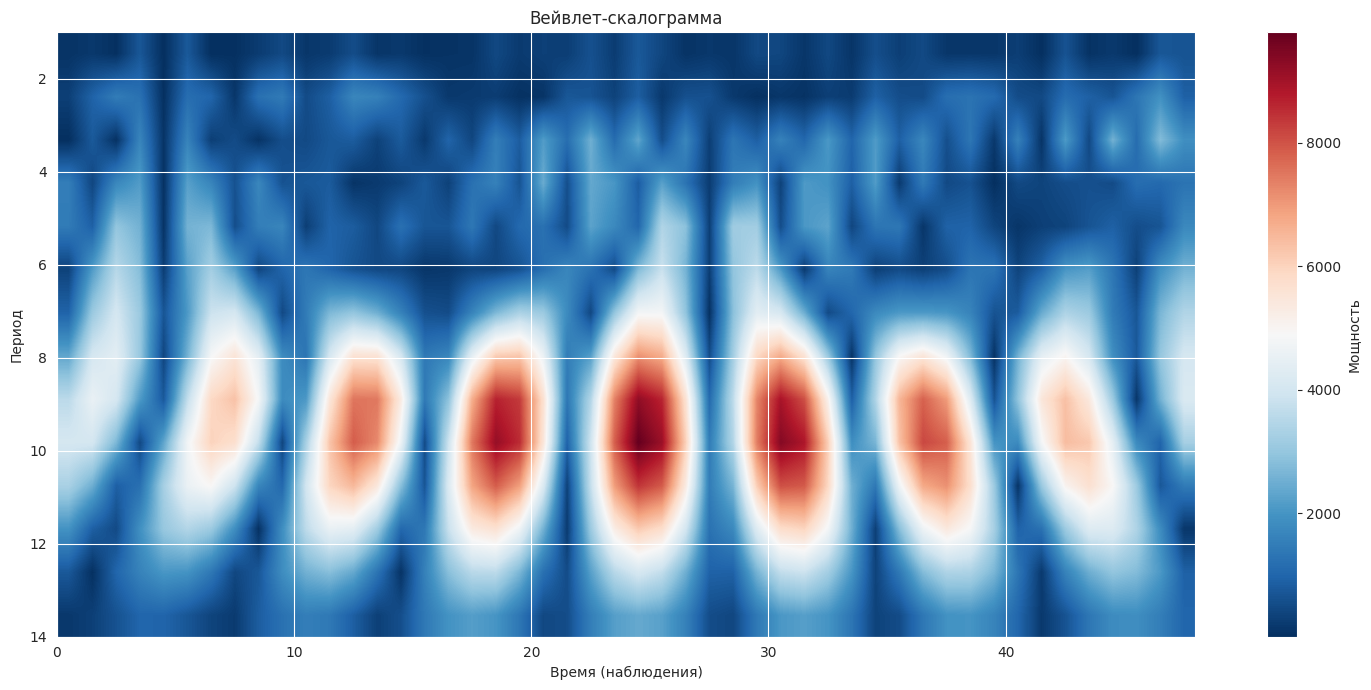

In [22]:
_, ax = plt.subplots(figsize=(15, 7))

scales = np.arange(1, 15)
coefficients = cwt(df['SalesAmountDetrended'], scales, 'morl', sampling_period=1)[0]

plt.imshow(
    np.abs(coefficients),
    extent=[0, df.shape[0], scales.max(), scales.min()],
    aspect='auto',
    cmap='RdBu_r',
    interpolation='bilinear'
)

plt.colorbar(label='Мощность')
plt.xlabel('Время (наблюдения)')
plt.ylabel('Период')
plt.title('Вейвлет-скалограмма')

plt.tight_layout()
plt.show()

Видим, что в разные периоды времени очень сильно активизируется 10-дневный цикл, для периода в 12 месяцев ж мощность остаётся низкой на протяжении всего ряда

Теперь с помощью вейвлета Добеши для 4 уровня можно выделить тренд, сезонность и шум, а также ряд без шума следующим образом - пусть у нас исходный ряд представляет собой сумму аппроксимаций A4 + D4 + D3 + D2 + D1, где:
- A4 - аппроксимация 4-ого уровня (самая грубая)
- D4 - детали 4-ого уровня (долгие циклы, 16 - 32 месяцев)
- D3 - детали 3-ого уровня (средние циклы, 8 - 16 месяцев)
- D2 - детали 2-ого уровня (короткие циклы, 4 - 8 месяцев)
- D1 - детали 1-ого уровня (очень короткие циклы (2 - 4 месяца) + шум)

Для того, чтобы выделить:
- Тренд, можно оставить только аппроксимацию 4-ого уровня A4
- Детали (сезонность + шум) - можно не учитывать тренд, то есть аппроксимацию 4-ого уровня A4
- Ряд без шума - можно не учитывать детали 1-ого уровня D1

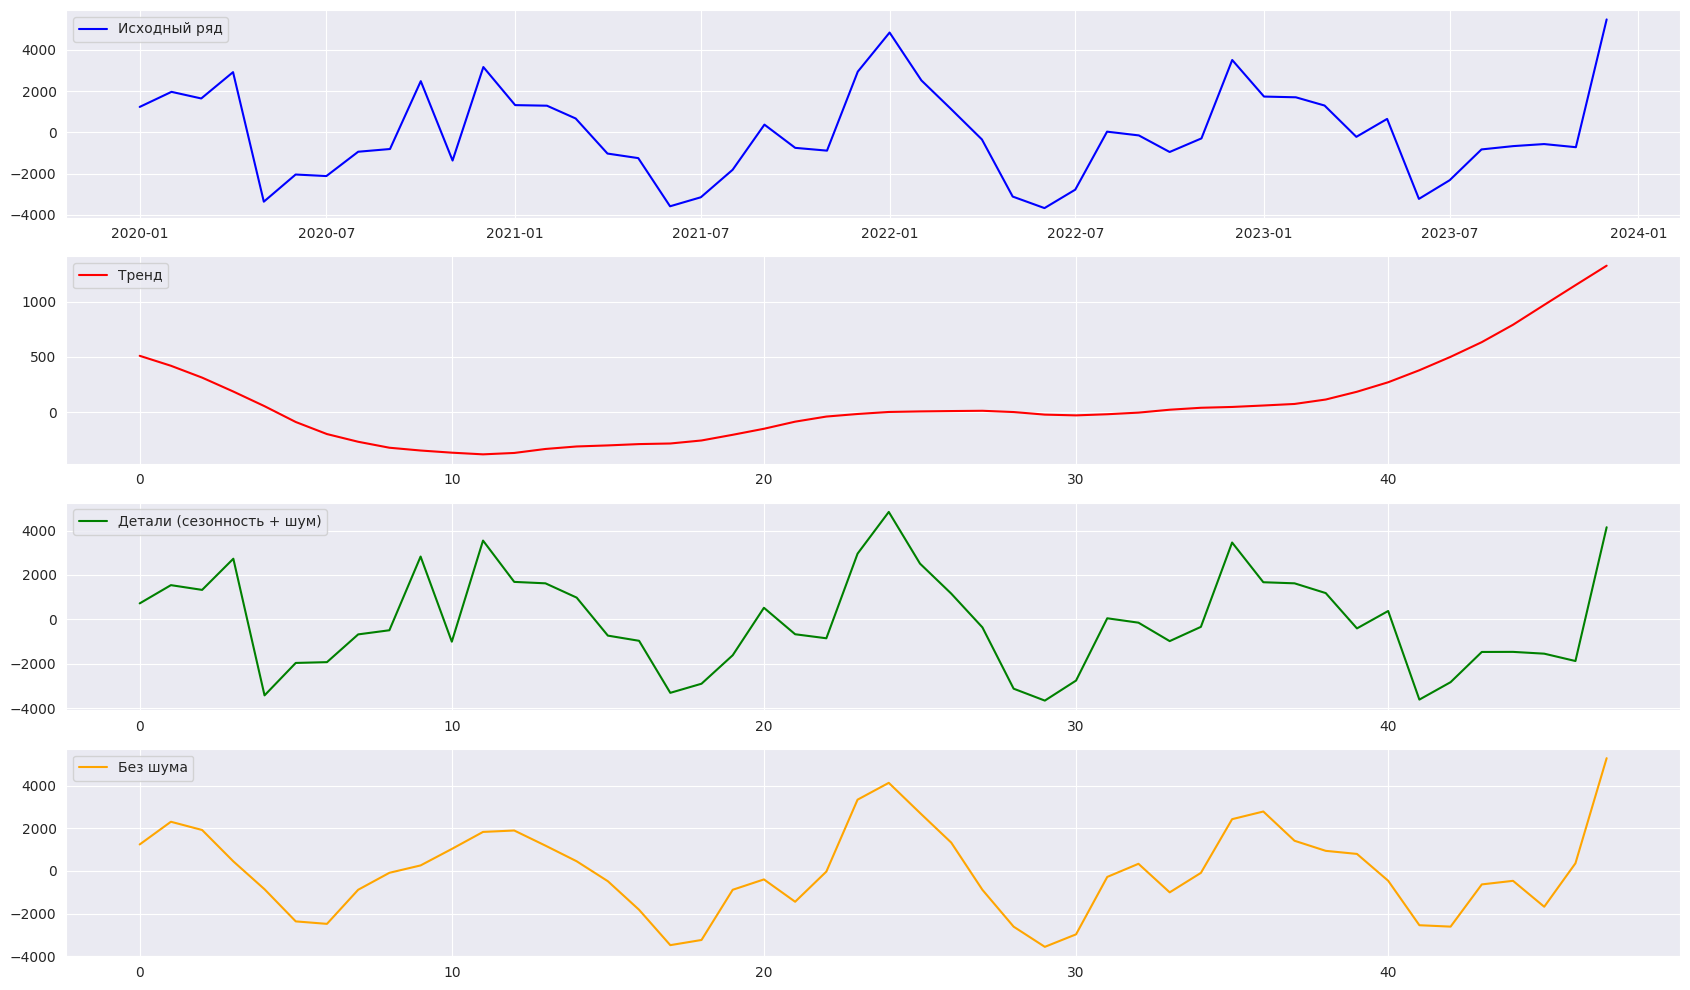

In [23]:
level = 4
wavelet = 'db4'
coefficients = wavedec(df['SalesAmountDetrended'], wavelet, level=level)

trend = waverec([coefficients[0]] + [np.zeros_like(c) for c in coefficients[1:]], wavelet)
detail = waverec([np.zeros_like(coefficients[0])] + coefficients[1:], wavelet)
denoised = waverec(coefficients[:-1] + [np.zeros_like(coefficients[-1])], wavelet)

_, axes = plt.subplots(nrows=4, figsize=(17, 10))

axes[0].plot(df['SalesAmountDetrended'], color='blue', label='Исходный ряд')
axes[1].plot(trend, color='red', label='Тренд')
axes[2].plot(detail, color='green', label='Детали (сезонность + шум)')
axes[3].plot(denoised, color='orange', label='Без шума')

for ax in axes:
    ax.legend()

plt.tight_layout()
plt.show()

Выводы следующие:
- У ряда таки наблюдается тренд, котрый сначала убывает, а потом возрастает (всё, как и в случае с сезонной декомпозицией)
- Детали очень сильно повторяют исходный ряд, значит тренд довольно плавный и не совершает каких-то резких скачков
- Ряд без шума очень напоминает ряд с деталями, нозначительно более сглаженный, без резких изломов

# Построение прогнозных моделей ARIMA и SARIMAX

Прежде всего разделим выборку на тренировочную и тестовую части так, чтобы в тренировочную попали первые 3 года наблюдений, а в тестовую - последний год

In [24]:
train_size = int(df.shape[0] * 0.75)
train, test = df[:train_size], df[train_size:]
endog_train, endog_test = train['SalesAmount'], test['SalesAmount']
exog_train, exog_test = train[['HolidayMonth', 'Promotion']], test[['HolidayMonth', 'Promotion']]
nlags = test.shape[0]

Будем осуществлять подбор гиперпараметром для моделей ARIMA и SARIMAX несколько необычным образом - для каждой обученной мдели будем проводить некоторые статистические тесты на основные важные характеристики остатков (гомоскедастичнсоть, некоррелированность, нормальность). Тесты объединяет одно - если p_value оказалось больше, чем заданныйуровень значимости (в моём случае это 0.05), то нулевая гипотеза об отсутствии какого-либо полезного свойства (гомоскедастичности, некоррелированности остатков) отвергается

Были выбраны следующие тесты:
- Тест Энгла (ARCH) - проверяет, есть ли в остатках авторегрессионная условная гетероскедастичность, то есть зависит ли сегодняшний разброс ошибок от вчерашнего
- Тест Бройша-Годфри - проверяет наличие автокорреляции любого порядка (до заданного лага) в модели. Он строит регрессию остатков на лаги и все исходные регрессоры
- Тест множителя Лагранжа - очень похож на тест Бройша-Годфри за исключением того, что регрессия строится только по лагам, а исходные регрессоры туда не включатся

НЕ рассматривались следующие тесты:
- Тест Бройша-Пагана - проверяет, зависит ли дисперсия от каких-то экзогенных переменных (я пробовал делать зависимость от времени). Тест строит регрессию над квадратами остатков, а регрессия очень чувствительна к выбросам, а ранние остатки в данной задаче действительно являются сильными выбросами. Поэтому нулевая гипотеза всегда будет отвергаться только на экстремально низких значениях p-value
- Тест Льюнга-Бокса - проверяет, являются ли остатки белым шумом, то есть отсутствует ли автокорреляция на группе лагов (в качестве группы я буду использовать лишь сезоный лаг, то есть 12-ый). Проблема в том, что при моделях, которые проходят этот тест (нулевая гипотеза отвергается), предсказания получаюся отвратительного качества, так как чтобы убрать автокорреляцию, нужна сложная модель, которая скорее всего переобучится
- Тест МакЛиода-Ли (по сути, это тест Льюнга-Бокса над квадратами остатков) - проверяет, есть ли авктокорреляция в квадратах остатков. Для модели SARIMAX, если этот тес пройден, то предсказания имеют плохое качество. Для остальных моделей такой проблемы нет, но SARIMAX ожидается наилучшей моделью, поэтому увы, при подборе гиперпарамтров от этого теста надо избавиться
- Тесты Шапиро-Уилка и Жарку-Бера - практика для данной задачи показывает, что если остатки гомоскедастичны во времени и не коррелируют друг с другом, то нормального распределения там и близко нет. А эти 2 свойства всё-таки важнее, чем нормальность

В дальнейшем тесты будут применены ко всем уже готовым обученным моделям, в том числе и вышеописанные тесты, которые при подборе гиперпараметров не рассматривались (кроме Бройша-Пагана)

**Важно** - у некоторых тестов надо обязательно указывать значение параметра `ddof` (то есть количество независимых наблюдений, которые остались после того, как мы оценили некторые параметры). В документации рекомендуют значение `p + q + P + Q`. Если этого не сделать, то p-value может быть неоправданно завышенным, что может создать иллюзию того, что тест пройден и нулевая гипотеза отвергнута

Итак, будут подбираться гиперпараметры для следующих 4 моделей:
- ARIMA
- ARIMAX (ARIMA с экзогенными переменными)
- SARIMA (SARIMAX без экзогенных переменных)
- SARIMAX

Каждая из 4 моделей будет выбрана с теми гиперпараметрами, которые проходят указанные тесты и при этом имеют минимальное значение метрики AIC. Если же ни один набор параметров не прошёл все тесты, то будет выбрана та модель, которая просто минимизирует AIC

In [25]:
def grid_search(
    model, endog, p_range, q_range,
    d_range=(0, 1), P_range=(0, 1), Q_range=(0, 1), D_range=(0, 1), s=0,
    exog=None, verbose=True, p_value=0.05,
    **kwargs
):
    best_aic, best_order, best_seasonal_order = np.inf, (0, 0, 0), (0, 0, 0, 0)
    spare_aic, spare_bic, spare_order, spare_seasonal_order = np.inf, np.inf, (0, 0, 0), (0, 0, 0, 0)
    found = False
    for p in range(*p_range):
        for q in range(*q_range):
            for d in range(*d_range):
                order = (p, d, q)
                for P in range(*P_range):
                    for Q in range(*Q_range):
                        for D in range(*D_range):
                            seasonal_order = (P, D, Q, s)
                            index = f'{order=}, {seasonal_order=}'
                            obj = model(
                                endog=endog,
                                exog=exog,
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            results = obj.fit(**kwargs)
                            resid = results.resid
                            ddof = obj.order[0] + obj.order[2] + obj.seasonal_order[0] + obj.seasonal_order[2]

                            p_values = np.array([
                                *het_arch(resid, nlags=nlags, ddof=ddof)[1::2],
                                *acorr_lm(resid, nlags=nlags, ddof=ddof)[1::2],
                                *acorr_breusch_godfrey(results, nlags=nlags)[1::2]
                            ])

                            if results.aic < spare_aic:
                                spare_aic, spare_bic, spare_order, spare_seasonal_order = results.aic, results.bic, order, seasonal_order

                            if results.aic < best_aic and (p_values >= p_value).all().item():
                                found = True
                                best_aic, best_order, best_seasonal_order = results.aic, order, seasonal_order
                                if verbose:
                                    print(
                                        f'Текущая наилучшая модель, где p-value всех тестов не ниже, чем {p_value} имеет следующие ' +
                                        f'гиперпараметры: {p=}, {d=}, {q=}, {P=}, {D=}, {Q=}, {s=}; AIC={round(results.aic, 5)}, BIC={round(results.bic, 5)}'
                                    )

    if not found:
         print(
             f'Не было найдено ни одной модели, где в каждом тесте p-value был бы меньше, чем {p_value}, так что будет выбрана модель, минимизирующая метрику AIC, ' +
             f'она имеет следующие гиперпараметры: \np={spare_order[0]}, d={spare_order[1]}, q={spare_order[2]}, P={spare_seasonal_order[0]}, ' +
             f'D={spare_seasonal_order[1]}, Q={spare_seasonal_order[2]}, {s=}; AIC={round(spare_aic, 5)}, BIC={round(spare_bic, 5)}'
         )
         best_order, best_seasonal_order = spare_order, spare_seasonal_order

    return model(
        endog=endog,
        exog=exog,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

Дальше просто будут получены лучшие модели ARIMA, ARIMAX, SARIMA, SARIMAX

По графикам обычной и частичной автокорреляции можно выделить следующие особенности подбора:
- `p` будет принимать значения 0, 1, 2
- `q` будет принимать значения 0, 1, 2
- `s` (сезонность) для моделей SARIMA и SARIMAX принимает значение 12
- `P` будет принимать значения 0, 1 (так как только на 12 лаге есть значимые пики в графиках автокорреляций)
- `Q` будет принимать значения 0, 1
- Параметр `cov_type` принимает знчение `robust`. Этот параметр отвечает за то, каким образом будет рассчитываться ковариационная матрица оценок. Значение `robust` означает, что стандартные ошибки будут устойчивы к гетероскедастичности

In [26]:
%%time
best_arima = grid_search(
    model=ARIMA,
    endog=endog_train,
    p_range=(0, 3),
    q_range=(0, 3),
    d_range=(0, 2),
    cov_type='robust'
)

Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=0, q=1, P=0, D=0, Q=0, s=0; AIC=620.83107, BIC=625.41015
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=0, q=2, P=0, D=0, Q=0, s=0; AIC=602.2322, BIC=608.21823
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=2, d=0, q=2, P=0, D=0, Q=0, s=0; AIC=591.83508, BIC=600.81413
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=2, d=1, q=2, P=0, D=0, Q=0, s=0; AIC=590.88332, BIC=598.212
CPU times: user 2.39 s, sys: 11.9 ms, total: 2.41 s
Wall time: 2.4 s


In [27]:
%%time
best_arimax = grid_search(
    model=ARIMA,
    endog=endog_train,
    p_range=(0, 3),
    q_range=(0, 3),
    d_range=(0, 2),
    exog=exog_train,
    cov_type='robust'
)

Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=0, q=1, P=0, D=0, Q=0, s=0; AIC=600.37124, BIC=608.00304
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=0, q=2, P=0, D=0, Q=0, s=0; AIC=574.13623, BIC=583.11528
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=2, d=1, q=1, P=0, D=0, Q=0, s=0; AIC=573.11615, BIC=582.0952
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=2, d=1, q=2, P=0, D=0, Q=0, s=0; AIC=558.28207, BIC=568.54222
CPU times: user 4.65 s, sys: 7.3 ms, total: 4.66 s
Wall time: 4.74 s


In [28]:
%%time
best_sarima = grid_search(
    model=SARIMAX,
    endog=endog_train,
    p_range=(0, 3),
    q_range=(0, 3),
    d_range=(0, 2),
    P_range=(0, 2),
    Q_range=(0, 2),
    D_range=(0, 2),
    s=12,
    cov_type='robust'
)

Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=1, q=0, P=0, D=1, Q=1, s=12; AIC=172.65834, BIC=173.26351
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=1, d=0, q=1, P=1, D=1, Q=1, s=12; AIC=171.69519, BIC=173.20811
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=2, d=1, q=0, P=1, D=1, Q=1, s=12; AIC=161.77099, BIC=162.75712
CPU times: user 1min 3s, sys: 125 ms, total: 1min 3s
Wall time: 46.3 s


In [29]:
%%time
best_sarimax = grid_search(
    model=SARIMAX,
    endog=endog_train,
    p_range=(0, 3),
    q_range=(0, 3),
    d_range=(0, 2),
    P_range=(0, 2),
    Q_range=(0, 2),
    D_range=(0, 2),
    s=12,
    exog=exog_train,
    cov_type='robust'
)

Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=1, q=0, P=0, D=0, Q=1, s=12; AIC=382.38475, BIC=386.74892
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=1, q=0, P=0, D=1, Q=1, s=12; AIC=170.64865, BIC=171.85899
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=0, d=1, q=1, P=0, D=1, Q=1, s=12; AIC=150.6948, BIC=151.68092
Текущая наилучшая модель, где p-value всех тестов не ниже, чем 0.05 имеет следующие гиперпараметры: p=1, d=0, q=2, P=0, D=1, Q=1, s=12; AIC=150.24086, BIC=151.62143
CPU times: user 1min 16s, sys: 158 ms, total: 1min 16s
Wall time: 44.1 s


# Оценка качества моделей

## Анализ остатков

Функция `get_model_title` направлена на то, чтобы извлечь имя модели и наборы `order` и `seasonal_order`

In [30]:
def get_model_title(model):
    is_arima = isinstance(model, ARIMA)
    title = 'ARIMA' if is_arima else 'SARIMA'
    if model.exog is not None:
        title += 'X'
    title += f', order={model.order}'
    if not is_arima:
        title += f', seasonal_order={model.seasonal_order}'
    return title

Итак, теперь получим p-value для всех упоминаемых ранее тестов для всех обученных моделей

In [31]:
def get_pvalues(*models, p_value=0.05, **kwargs):
    results = [model.fit(**kwargs) for model in models]
    resid = [result.resid for result in results]
    ddofs = [model.order[0] + model.order[2] + model.seasonal_order[0] + model.seasonal_order[2] for model in models]

    stats = pd.DataFrame(
        np.array([
            [
                *het_arch(resid[i], nlags=nlags, ddof=ddofs[i])[1::2],
                acorr_ljungbox(np.square(resid[i]), lags=[nlags], model_df=ddofs[i])['lb_pvalue'].iloc[0],
                *acorr_lm(resid[i], nlags=nlags, ddof=ddofs[i])[1::2],
                *acorr_breusch_godfrey(results[i], nlags=nlags)[1::2],
                acorr_ljungbox(resid[i], lags=[nlags], model_df=ddofs[i])['lb_pvalue'].iloc[0],
                shapiro(resid[i])[1],
                jarque_bera(resid[i])[1]
            ] for i in range(len(models))
        ]),
        columns=[
            'ARCH Engle (L)',
            'ARCH Engle (F)',
            'Ljung-Box (squares)',
            'Lagrange Multiplier (L)',
            'Lagrange Multiplier (F)',
            'Breusch-Godfrey (L)',
            'Breusch-Godfrey (F)',
            'Ljung-Box',
            'Shapiro-Wilk',
            'Jarque-Bera'
        ],
        index=[get_model_title(model) for model in models]
    )
    return stats.style.applymap(lambda value: f'font-weight: {"normal" if value < p_value else "bold"}')

In [32]:
get_pvalues(best_arima, best_arimax, best_sarima, best_sarimax, cov_type='robust')

,ARCH Engle (L),ARCH Engle (F),Ljung-Box (squares),Lagrange Multiplier (L),Lagrange Multiplier (F),Breusch-Godfrey (L),Breusch-Godfrey (F),Ljung-Box,Shapiro-Wilk,Jarque-Bera
"ARIMA, order=(2, 1, 2)",0.675971,0.648450,0.991049,0.367375,0.191303,0.623928,0.711163,0.026861,0.000246,0.000000
"ARIMAX, order=(2, 1, 2)",0.469517,0.338292,0.965785,0.443382,0.299194,0.295289,0.436986,0.328762,0.000001,0.000000
"SARIMA, order=(2, 1, 0), seasonal_order=(1, 1, 1, 12)",0.239090,0.050327,0.149298,0.337094,0.152121,0.350027,0.392302,0.000165,0.012362,0.000112
"SARIMAX, order=(1, 0, 2), seasonal_order=(0, 1, 1, 12)",0.493068,0.373990,0.047556,0.263275,0.071085,0.230013,0.326333,0.009145,0.000017,0.000000


Можно отметить следующее (уровень значимости для тестов - 0.05):
- Для малых выборок (а у нас в тренировочной только 36 объектов), F-статистика (помечены буквой F) будет лучше, чем статистика Лагранжа (помечены буквой L), поэтому первое внимание будем обращать именно на p-value, полученные с помощью F-статистики
- Модель SARIMA с большим скрипом проходит тест Энгла на условную гомоскедастичность, тогда как остальные модеи делают это довольно уверенно
- Модели ARIMA и ARIMAX очень уверенно проходят тест МакЛиода-Ли (тест Льюнга-Бокса на квадратах остатков), SARIMA тоже проходит, а вот SARIMAX, увы, нет. Хотя значение и близко к 0.05
- Модели SARIMA и SARIMAX менее уверенно проходят тест множителя Лагранжа, чем модели ARIMA и ARIMAX
- Все модели достаточно уверенно прошли тест Бройша-Годфри
- Лишь модель ARIMAX прошла тест Льюнга-Бокса, ARIMA превычисла лишь значение 0.025, а SARIMA и SARIMAX имеют очень малые значения p-value
- Тесты на нормальность остатков ни одна модель не прошла

Теперь напишем функцию `plot_resids_stats`, которая для каждой обученной модели строит 4 графика:
- График распределения остатков во времени (по нему можно визуально определить наличие или отсутствие гомоскедастичности)
- Граифк распределения значений остатков (по нему можно визуально определить нормальность или ненормальность остатков)
- QQ-plot (по нему визуально можно определить, соответствует ли распределение некоему теоретическому (в нашем случае - нормальному))
- График автокорреляции остатков

In [33]:
def plot_resids_stats(model, figsize=(15, 9), **kwargs):
    _, axes = plt.subplots(nrows=2, ncols=2, figsize=figsize)

    resid = model.fit(**kwargs).resid

    axes[0][0].scatter(range(resid.shape[0]), resid, color='blue')
    axes[0][0].hlines(y=0, xmin=0, xmax=resid.shape[0], color='red', linestyles='--')
    axes[0][0].set_title('График распределения остатков модели по времени')

    sns.histplot(resid, ax=axes[0][1], kde=True, color='blue')
    axes[0][1].set_title('График распределения значений остатков')

    qqplot(resid, line='45', fit=True, ax=axes[1][0])
    axes[1][0].set_title('График QQ-Plot для ошибок')
    axes[1][0].set_xlabel('Теоретические квантили')
    axes[1][0].set_ylabel('Квантили в выборке')

    plot_acf(resid, ax=axes[1][1], title='Автокорреляция остатков', lags=nlags)
    axes[1][1].legend()

    plt.suptitle(get_model_title(model))
    plt.tight_layout()
    plt.show()

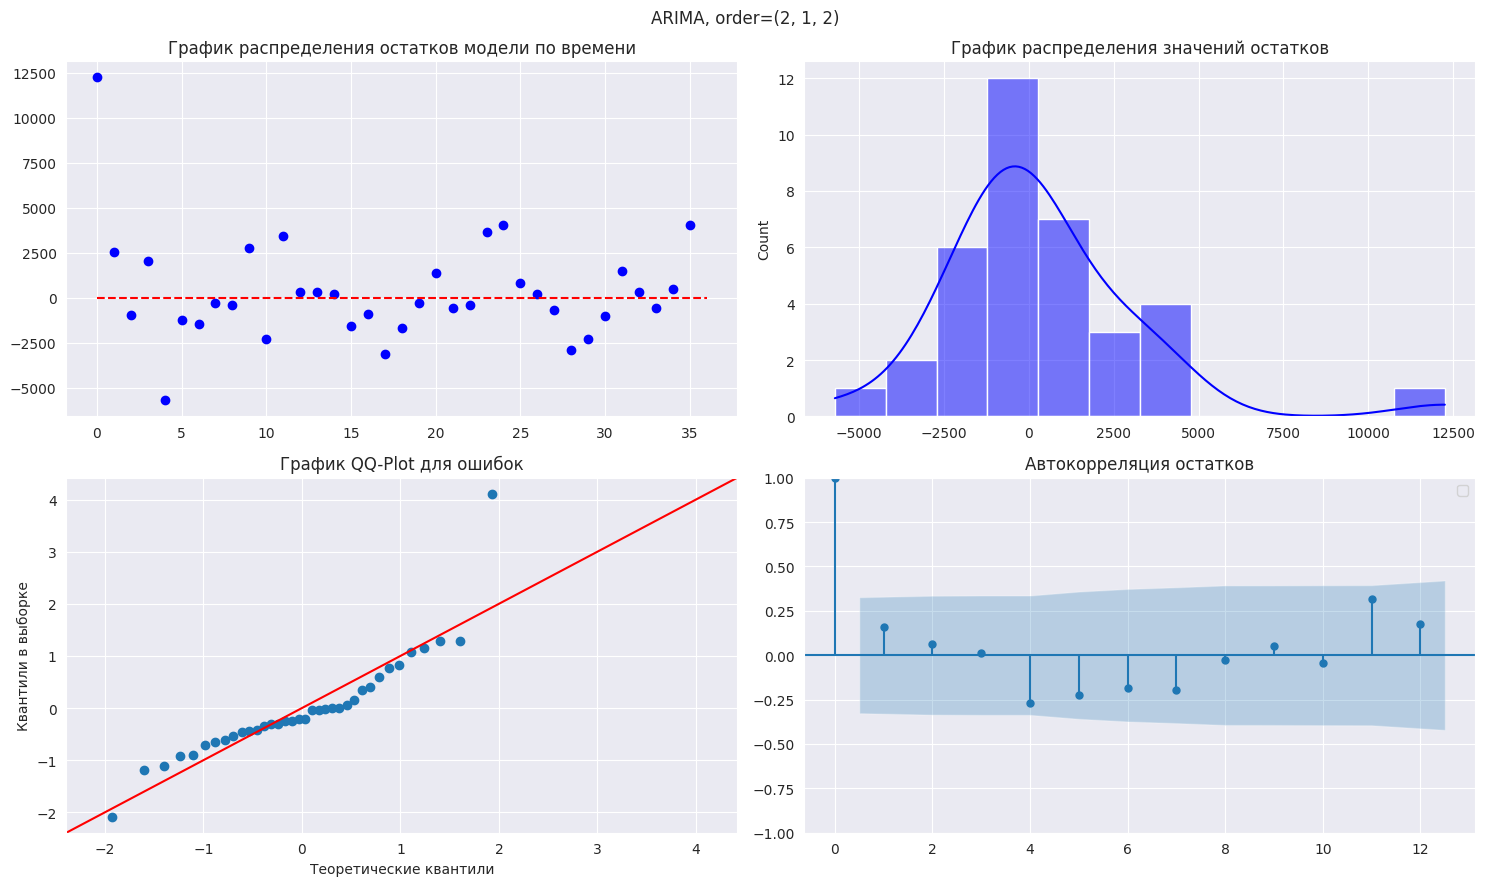

In [34]:
plot_resids_stats(best_arima, cov_type='robust')

Итак, для модели ARIMA делаем следующие выводы:
- Если бы не выбросы со значениями 12500 и -5500, то чисто визуально дисперсию можно считать константной на всём протяжении ряда
- Из-за положительного выброса распределение не похоже на нормальное, да и столбец в районе 5000 больше, чем столбец в районе 2500, например
- По графику QQ-plot видно, что слева точки в основном находятся выше линии, то есть у исходного распределения слева более лёгкий хвост, чем у нормального. В центре точки ниже графка, то есть медиана остатков занижена, и систематически прогнозы тоже. Справа в оновном значения тоже занижены, то есть справа более лёгкий хвост, чем у нормального распределения. Однако имеется положительный выброс, "благодаря" которому точка находится сильно выше линии
- График автокорреляции остатков показывает, что для всех лагов вплоть до сезонного, автокорреляция не значима

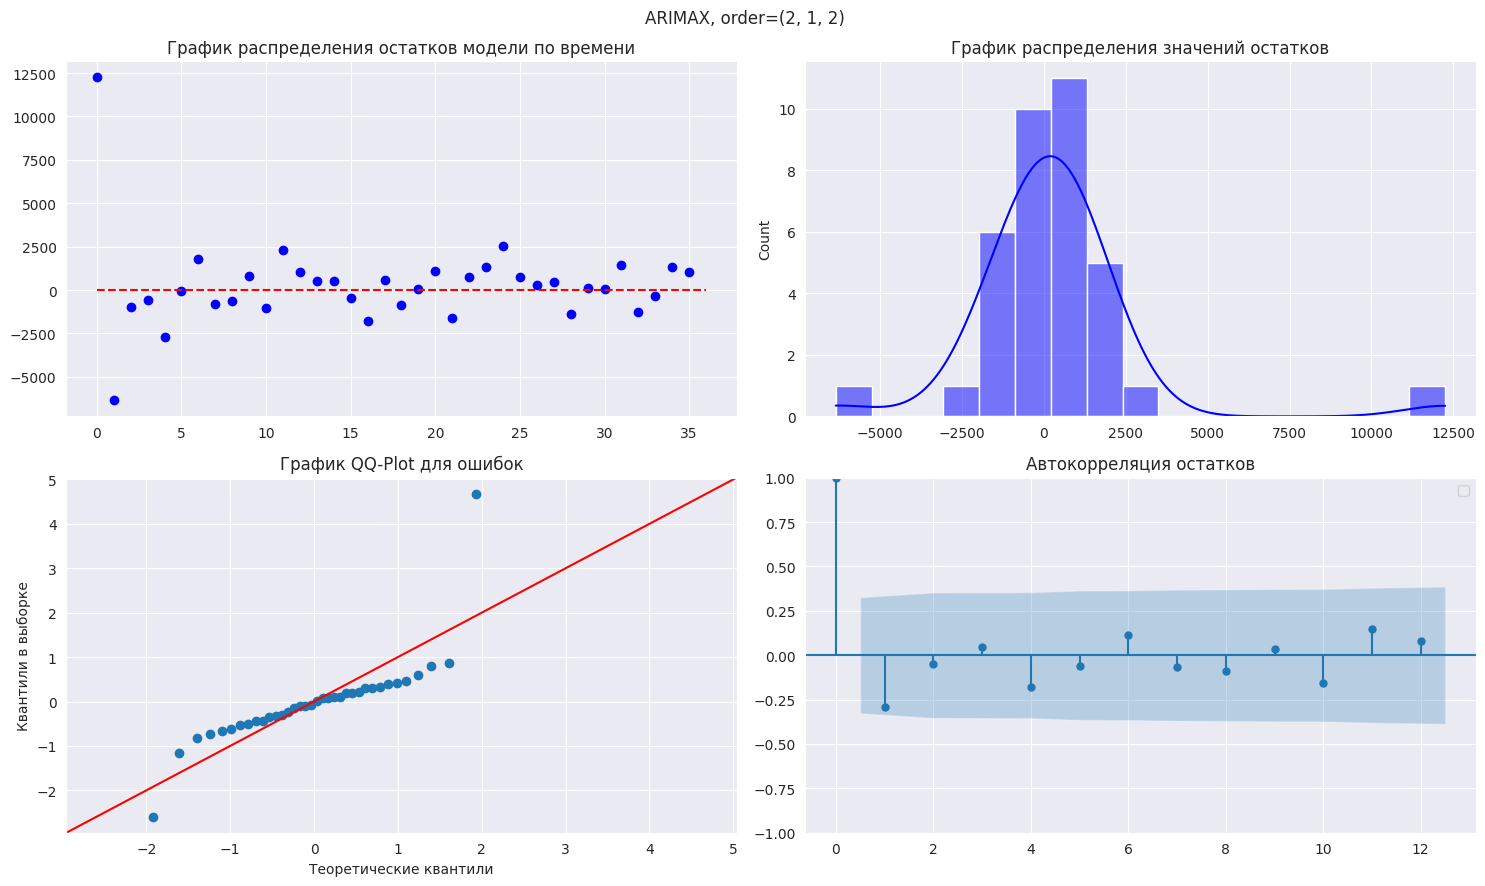

In [35]:
plot_resids_stats(best_arimax, cov_type='robust')

Итак, для модели ARIMAX делаем следующие выводы:
- Та же проблема с выбросами, что и у модели ARIMA, без них дисперсию остатков можно было бы считать константной во времени
- Теперь чем ближе толбец к среднему, тем он выше, однако выбросы опть всё портят
- На графике QQ-plot прорисовывается характерная S-образная кривая, то есть слева точки выше линии (более лёгкий хвост, чем у нормального распределения), а справа ниже (также более лёгкий хвост, чем у нормального распределения). Ну и выбросы тоже вносят свой вклад
- Автокорреляция не значима, как и у модели ARIMA

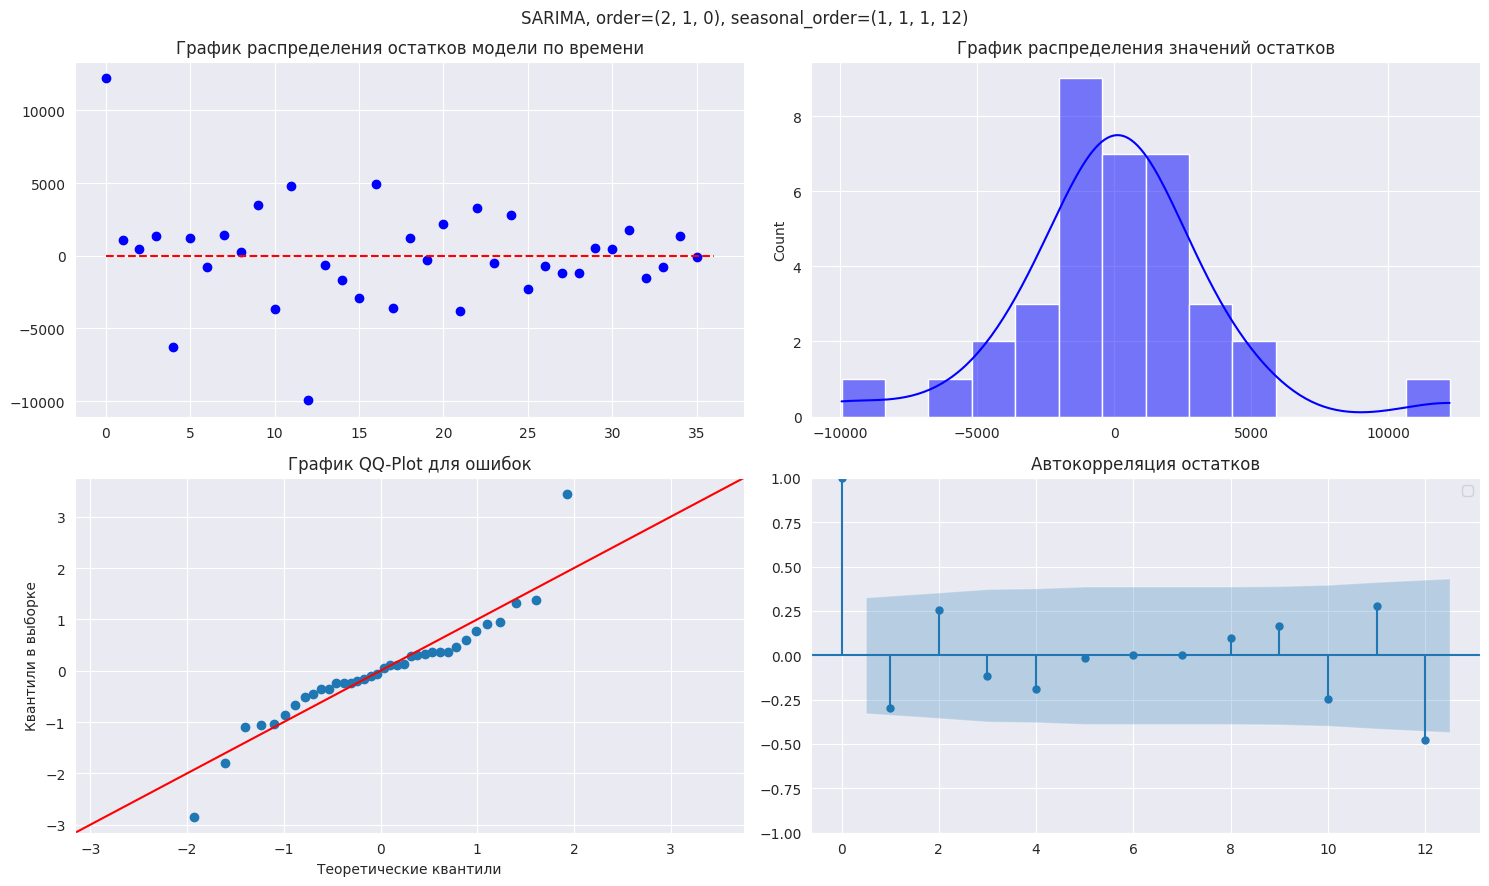

In [36]:
plot_resids_stats(best_sarima, cov_type='robust')

Итак, для модели SARIMA делаем следующие выводы:
- Выбросы есть также, однако даже без них можно визуально разглядеть, как дисперсия плавно уменьшается со временем, так что вряд ли можно утверждать о гомоскедастичности остатков
- Тут и выбросы мешают распределению быть нормальным, и правый хвост у их распределения резко уменьшается, и самый высокий столбец также не рядом со средним
- График QQ-plot для модели SARIMA поход на аналогичный у ARIMA, выводы тоже можно сделать соответствующими
- Автокорреляция с сезонным 12-ым лагом оказывается значимой, однако я всё же решил этим пренебречь, так как размер тестовой выборки как раз равняется 12 и мы по сути делаем предсказания на 1 сезон всего лишь

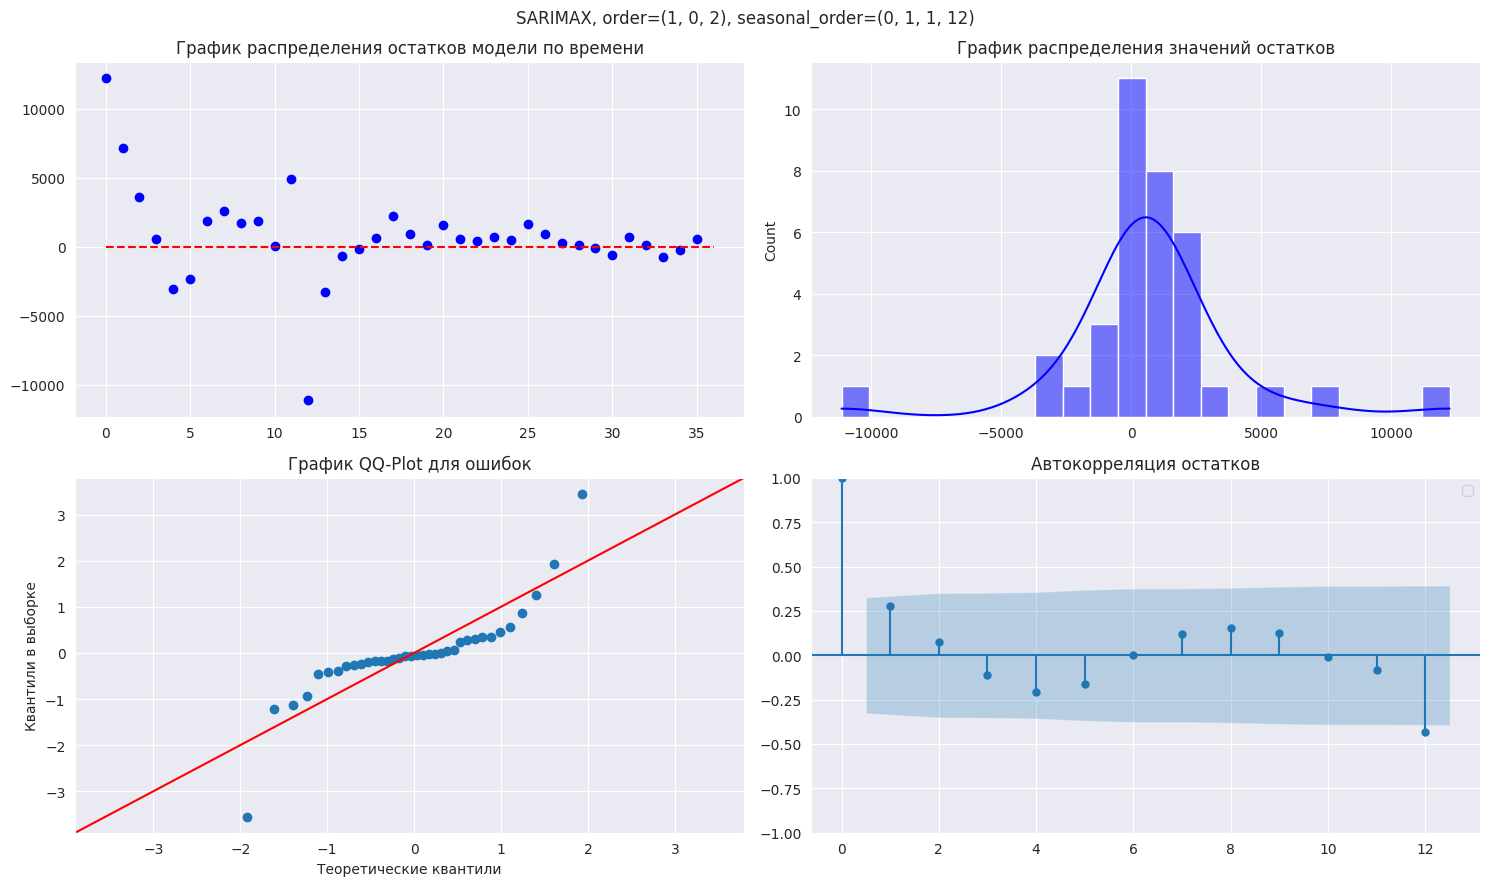

In [37]:
plot_resids_stats(best_sarimax, cov_type='robust')

Итак, для модели SARIMAX делаем следующие выводы:
- Тут уменьшение дисперсии ещё более заметно
- Очень много выбросов - раз. Столбцы резко меняют свою высоту, которая не зависит от дальноти от центра - два. Ну и тут слишком тяжёлые хвосты получаются у распределения - три. Нормальности нет
- S-образная кривая на графике QQ-plot ещё более "горизонтальная", чем у такой на графике QQ-plot для ARIMAX, то есть распрееление получилось ещё и сильно суженным
- Также значима автокорреляция с сезонным 12-ым лагом

## Получение метрик

Теперь напишем функцию `get_metrics`, с помощью которой получим значения следующих метрик для тестовой выборки:
- Среднеквадратичная ошибка (MSE)
- Средняя абсолютная ошибка (MAE) - не так сильно штрафует выбросы, как MSE
- Средняя абсолютная процентная ошибка (MAPE) - сосредотачивается не на абсолютных значениях отклонений, а на процентных. Так как среди данных нет околонулевых значений, то и у этой метрики не бдет экстремально высоких значений
- $R^2$ - метрика, показывающая долю дисперсии зависимой переменной, объяснённую моделью. Значение может быть в диапазоне от $-\infty$ до 1. Чем ближе значений к 1, тем более качественной считается модель
- Dynamic time wrapping (DTW, динамическое искажение времени) - метрика расстояния между двумя временными рядами. Метрика сравнивает ошибки в амплитуде, ошибки во времени и ошибки в форме рядов. Чем меньше значение (которое неотрицательо), тем более похожими считаются ряды
- Нормализованное DTW. Так как ряды нормализованы, то ошибки в амплитуде значений больше не учитываются, а сраниваются лишь формы и запаздывания по времени
- Directional accuracy (DA, направленная точность) - метрика оценивает правильность направлений изменений временного ряда. Метрика не зависит от масштаба и устойчива к выбросам, однако она не учитывает масштаб предсказаний

Для тренировочной выборки вычисляются следующие метрики (так как для тестовой их вычислить нельзя):
- Информационный критерий Акаике (AIC) и Байесовский информационный критерий (BIC). Оба критерия штрафуют модели как за плохую подгонку гиперпараметров, так и за сложность самой модели. Абсолютные значения этих метрик ничего не значат, по ним лишь сравниваются несколько моделей и выбирается та, где значения метрик наименьшие

In [38]:
def get_metrics(*models, test, exog, **kwargs):
    results = [model.fit(**kwargs) for model in models]
    forecasts = [
        results[i].get_forecast(
            steps=test.shape[0],
            exog=(exog if models[i].exog is not None else None)
        ).predicted_mean.values for i in range(len(models))
    ]

    metrics = pd.DataFrame(
        np.array([[
            mean_squared_error(test, forecasts[i]),
            mean_absolute_error(test, forecasts[i]),
            mean_absolute_percentage_error(test, forecasts[i]),
            r2_score(test, forecasts[i]),
            np.sqrt(dtw.distance(test, forecasts[i])),
            np.sqrt(dtw.distance(
                StandardScaler().fit_transform(test.values[:, None]),
                StandardScaler().fit_transform(forecasts[i][:, None])
            )),
            np.mean(np.sign(np.diff(test)) == np.sign(np.diff(forecasts[i]))),
            results[i].aic,
            results[i].bic
        ] for i in range(len(models))]),
        columns=['MSE', 'MAE', 'MAPE', 'R^2', 'DTW', 'Normalized DTW', 'DA', 'AIC', 'BIC'],
        index=[get_model_title(model) for model in models]
    )
    metrics['MSE'] = metrics['MSE'].apply(lambda x: '%.5f' % x)
    return metrics

In [39]:
get_metrics(best_arima, best_arimax, best_sarima, best_sarimax, test=endog_test, exog=exog_test, cov_type='robust')

,MSE,MAE,MAPE,R^2,DTW,Normalized DTW,DA,AIC,BIC
"ARIMA, order=(2, 1, 2)",4788799.42190,1400.621725,0.105631,-0.035449,85.250999,2.028657,0.636364,590.883323,598.212002
"ARIMAX, order=(2, 1, 2)",3544973.70290,1501.408556,0.115046,0.233495,75.730792,1.453971,0.818182,558.282069,568.542221
"SARIMA, order=(2, 1, 0), seasonal_order=(1, 1, 1, 12)",1788421.45369,1080.141843,0.082890,0.613302,62.975743,1.253504,0.727273,161.770995,162.757118
"SARIMAX, order=(1, 0, 2), seasonal_order=(0, 1, 1, 12)",862697.48892,579.034613,0.043309,0.813465,56.618182,1.137918,0.636364,150.240857,151.621429


Можно сделать следующие выводы по значениям метрик:
- Модели ARIMA, ARIMAX, SARIMA и SARIMAX ожидаемо (лично для меня) отсортированы по убыванию значений метрик MSE, MAE, MAPE
- У модели ARIMA значение метрики $R^2$ отрицательное, что говорит о том, что эта модель хуже, чем просто предсказание среднего. У остальных моделей значения метрик положительные, а у SARIMAX даже превышает 0.8
- По метрикам DTW модели также отсортированы в порядке убывания
- А вот по метрике DA наилучшей оказалась модель ARIMAX, что говорит о том, что она лучше всех предсказывает изменения направлений ряда. SARIMA оказалась похуже, а худшими - ARIMA и SARIMAX
- SARIMAX оказалась лучшей моделью по метрикам AIC и BIC и чуть лучше, чем SARIMA. Это может говорить о том, что добавление сезонной компоненты лучше объясняет поведение ряда

## Визуализация прогнозов

С помощью функции `plot_forecasts` отрисуем для каждой модели не только тренировочную и тестовую выборки и предсказания, но также и доверительный интервал, в котором они находятся. p-value опять возьмём равное 0.05

In [40]:
def plot_forecasts(*models, train, test, exog, p_value=0.05, nrows=1, ncols=1, figsize=(15, 7), **kwargs):
    axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)[1].flatten()
    for ax, model in zip(axes, models):
        ax.plot(train, color='blue', label='Тренировочные данные')
        ax.plot(test, color='green', label='Тестовые данные')

        local_exog = exog if model.exog is not None else None
        forecasts = model.fit(**kwargs).get_forecast(steps=test.shape[0], exog=local_exog)
        summary_frame = forecasts.summary_frame(alpha=p_value)

        ax.plot(summary_frame['mean'], color='red', label='Предсказания')
        ax.fill_between(
            summary_frame.index,
            summary_frame['mean_ci_lower'],
            summary_frame['mean_ci_upper'],
            color='lightcoral',
            label=f'Доверительный интервал предсказаний для уровня значимости {p_value}',
            alpha=0.4,
        )

        ax.set_title(get_model_title(model))
        ax.legend()

    plt.suptitle('Прогнозы моделей на тестовой выборке')
    plt.tight_layout()
    plt.show()

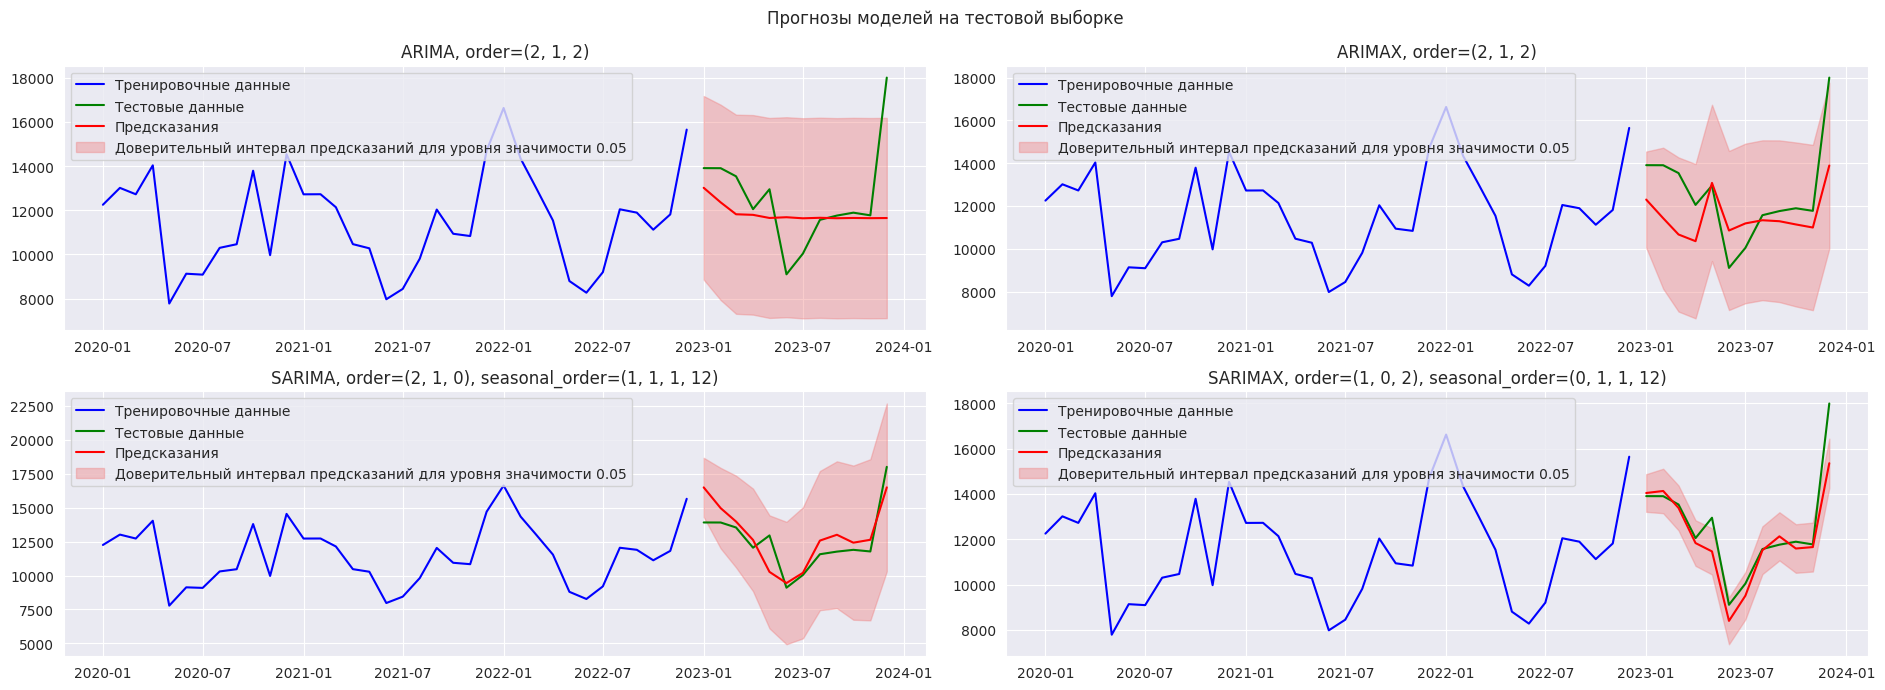

In [41]:
plot_forecasts(
    best_arima,
    best_arimax,
    best_sarima,
    best_sarimax,
    train=endog_train,
    test=endog_test,
    exog=exog_test,
    nrows=2,
    ncols=2,
    figsize=(19, 7)
)

Выводы следующие:
- У модели ARIMA ряд постепенно вырождается в константу, то есть отсутствие сезонной компоненты и экзогенных переменных негавтино влияет на качество предсказаний даже на столь малой по размеру тестовой выборке
- В модели ARIMAX были добавлены экзогенные переменные и модель стала хорошо улавливать изменения направления ряда, однако хорошо предсказывать отклонения у неё по-прежнему не получается
- Модель SARIMA имеет сезонную компоненту, но не имеет экзогенных переменных, и тем не менее уже хорошо повторяет форму ряда, однако траектория слишком плавная и изломы предсказываются не очень хорошо
- Ну и гвоздь сегодняшней программы - SARIMAX, которая является наилучшей моделью из всех. Тут и пики хорошо предсказываются, и форма ряда повторяется хорошо, и предсказанные значения (кроме последнего лага), очень близки к реальным. Вот так вот влияет добавление экзогенных переменных к сезонной компоненте может дать хороший рост качества модели